In [1]:
import os
from sklearn.pipeline import Pipeline
from model_class.feature_builder_clean_v2 import FeatureBuilder
from model_class.feature_builder_transformer import FeatureBuilderTransformer
from sklearn.feature_selection import mutual_info_classif
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import SGDOneClassSVM
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import FunctionTransformer
from sklearn.metrics import roc_auc_score, roc_curve


### 1. Import data

In [2]:
# Get the current directory
current_directory = os.getcwd()
    
# Get the source file path
file_path = f'{current_directory}/datasets/raw'
file = f"{file_path}/labelled_training_data.csv"
df_train = pd.read_csv(file, header=0)
y_train = df_train['evil']
X_train = df_train.drop(columns=['sus', 'evil'])

# Get the source file path
file_path = f'{current_directory}/datasets/raw'
file = f"{file_path}/labelled_testing_data.csv"
df_test = pd.read_csv(file, header=0)
y_test = df_test['evil']
X_test = df_test.drop(columns=['sus', 'evil'])

# Get the source file path
file_path = f'{current_directory}/datasets/raw'
file = f"{file_path}/labelled_validation_data.csv"
df_validation = pd.read_csv(file, header=0)
y_validation = df_validation['evil']
X_validation = df_validation.drop(columns=['sus', 'evil'])

In [3]:

def evaluate_model(y_true, y_pred, dataset_type="Dataset"):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    # Get unique values and their counts in y_true
    unique_values, counts = np.unique(y_true, return_counts=True)
    print(f"y_true_{dataset_type} Unique values: {unique_values}")
    print(f"y_true_{dataset_type} Counts of each value: {counts}")

    # Get unique values and their counts in y_pred
    unique_values, counts = np.unique(y_pred, return_counts=True)
    print(f"y_pred_{dataset_type} Unique values: {unique_values}")
    print(f"y_pred_{dataset_type} Counts of each value: {counts}")

     # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    print("Confusion Matrix:")
    print(cm)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Inlier", "Outlier"])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix for {dataset_type}')
    plt.show()

    # ROC AUC Score
    roc_auc = roc_auc_score(y_true, y_pred)
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    fnr = 1-tpr
    tnr = 1-fpr

    print(f"False Positive Rate: {fpr}")
    print(f"True Positive Rate: {tpr}")
    print(f"False Negative Rate: {fnr}")
    print(f"True Negative Rate: {tnr}")


    if dataset_type == "Test Dataset":
        plt.figure()
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'Receiver Operating Characteristic for {dataset_type}')
        plt.legend(loc="lower right")
        plt.show()

### 2. build features and train the model

In [4]:
count_cols = [
    "processId_eventId_past_count",
    "processId_past_count",
    "threadId_past_count",
    "eventId_past_count",
    "userId_past_count",
    "parentProcessId_past_count",
    "mountNamespace_past_count",
]

rarity_cols = [
    "processId_eventId_rarity",
    "processId_rarity",
    "threadId_rarity",
    "eventId_rarity",
    "userId_rarity",
    "parentProcessId_rarity",
    "mountNamespace_rarity",
]

scale_cols = [
    "stackAddresses_len",
    "stackAddresses_unique_ratio",
    "child_process_spawn_rate_so_far",
]

binary_cols = [
    "userId_binary",
    "parentUserId_binary",
    "returnValue_is_error",
    "args_has_path",
    "processId_eventId_is_first_seen",
    "processId_is_first_seen",
    "threadId_is_first_seen",
    "eventId_is_first_seen",
    "userId_is_first_seen",
    "parentProcessId_is_first_seen",
    "mountNamespace_is_first_seen"
]

passthrough_cols = [
    "argsNum",
    "returnValue",
]

log_count_pipeline = Pipeline([
    ("log", FunctionTransformer(
        lambda x: np.log1p(np.clip(x, 0, None)),
        feature_names_out="one-to-one",
        validate=False
    )),
    ("scale", RobustScaler()),
])

rarity_pipeline = Pipeline([
    ("scale", RobustScaler()),
])

scale_pipeline = Pipeline([
    ("scale", RobustScaler()),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("count", log_count_pipeline, count_cols),
        ("rarity", rarity_pipeline, rarity_cols),
        ("scale_other", scale_pipeline, scale_cols),
        ("binary", "passthrough", binary_cols),
        ("pass", "passthrough", passthrough_cols),
    ]
)

In [5]:
model = Pipeline([
    ("features", FeatureBuilderTransformer(FeatureBuilder(), return_numpy=False)),
    ("scaler", preprocessor),
    ("clf", SGDOneClassSVM(nu=0.05, random_state=42)),
])

763144 rows before feature engineering
763144 rows after merging parent process info
763144 rows after frequency encoding
763144 Null value counts after imputation
parent_timestamp null value count: 434615
763144 rows after processing parent and child process info and relationship
763144 rows after processing stackAddresses info
763144 rows after processing arg info
count__processId_eventId_past_count min= -2.7608823111961103 max= 2.0545232353784657 std= 0.8071519549367815


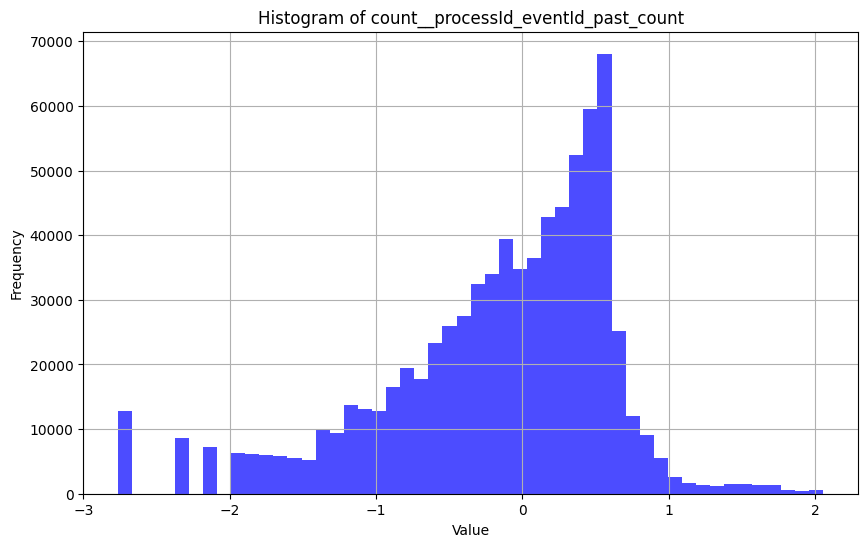

count__processId_past_count min= -4.674991792139068 max= 2.5377696074199405 std= 0.9057030631291093
count__threadId_past_count min= -4.624797066434414 max= 2.513874450765247 std= 0.904778883342952
count__eventId_past_count min= -5.568699571632947 max= 1.0081949956073155 std= 0.8902074579459124
count__userId_past_count min= -8.57563136601773 max= 1.0358509690923985 std= 0.9884060979674777
count__parentProcessId_past_count min= -5.382273351106752 max= 1.0013728140937896 std= 0.8328843382657761
count__mountNamespace_past_count min= -8.611827112302384 max= 1.03555078856469 std= 0.9733331297051521
rarity__processId_eventId_rarity min= -2.853116240651213 max= 2.988349594131072 std= 0.8427306469317942
rarity__processId_rarity min= -2.5410918720312776 max= 4.122742008475901 std= 0.858469790193625
rarity__threadId_rarity min= -2.517018915455605 max= 4.0818793908043585 std= 0.8543362549807593
rarity__eventId_rarity min= -3.8581975749023445 max= 34.85933154492299 std= 3.616714215146341
rarity__us

In [6]:
X_train_transformed = model[:-1].fit_transform(X_train)
feature_names = model.named_steps["scaler"].get_feature_names_out()
X_train_arr = np.asarray(X_train_transformed)

for i, col in enumerate(feature_names):
    vals = X_train_arr[:, i]
    print(
        col,
        "min=", np.nanmin(vals),
        "max=", np.nanmax(vals),
        "std=", np.nanstd(vals)
    )
    if col == "count__processId_eventId_past_count":
        plt.figure(figsize=(10, 6))
        plt.hist(vals, bins=50, color='blue', alpha=0.7)
        plt.title(f'Histogram of {col}')
        plt.xlabel('Value')
        plt.ylabel('Frequency')
        plt.grid(True)
        plt.show()

In [7]:
feature_importances = mutual_info_classif(X_train_transformed, y_train)
feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": feature_importances
}).sort_values(by="importance", ascending=False)
feature_importance_df.to_csv("features_data/feature_importances_isolation_forest.csv", index=False)

Fitting model using training data...
763144 rows before feature engineering
763144 rows after merging parent process info
763144 rows after frequency encoding
763144 Null value counts after imputation
parent_timestamp null value count: 434615
763144 rows after processing parent and child process info and relationship
763144 rows after processing stackAddresses info
763144 rows after processing arg info
763144 rows before feature engineering
763144 rows after merging parent process info
763144 rows after frequency encoding
763144 Null value counts after imputation
parent_timestamp null value count: 434615
763144 rows after processing parent and child process info and relationship
763144 rows after processing stackAddresses info
763144 rows after processing arg info


Text(0.5, 1.0, 'train_scores distribution')

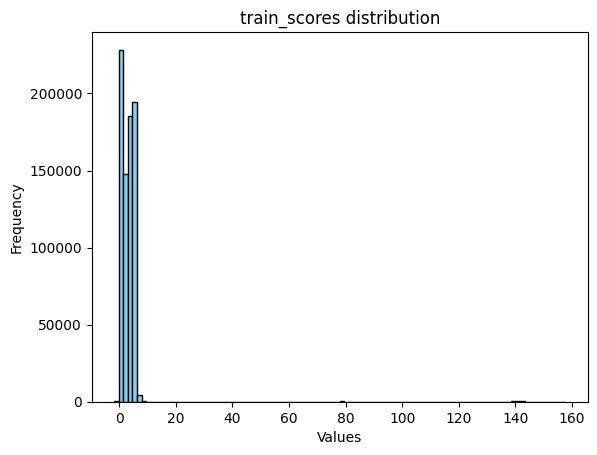

In [8]:
print("Fitting model using training data...")
model.fit(X_train)

# get Train scores
train_scores = model.decision_function(X_train)
# Plotting a basic histogram
plt.hist(train_scores, bins=100, color='skyblue', edgecolor='black')

# Adding labels and title
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('train_scores distribution')

763144 rows before feature engineering
763144 rows after merging parent process info
763144 rows after frequency encoding
763144 Null value counts after imputation
parent_timestamp null value count: 434615
763144 rows after processing parent and child process info and relationship
763144 rows after processing stackAddresses info
763144 rows after processing arg info
y_true_Train Dataset Unique values: [0]
y_true_Train Dataset Counts of each value: [763144]
y_pred_Train Dataset Unique values: [0 1]
y_pred_Train Dataset Counts of each value: [720128  43016]
Confusion Matrix:
[[720128  43016]
 [     0      0]]


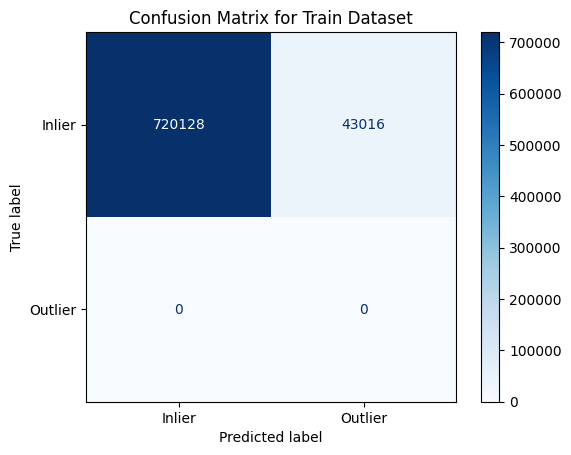

False Positive Rate: [0.         0.05636682 1.        ]
True Positive Rate: [nan nan nan]
False Negative Rate: [nan nan nan]
True Negative Rate: [1.         0.94363318 0.        ]


/Users/cheesecake/.pyenv/versions/anamoly-detection/lib/python3.14/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/cheesecake/.pyenv/versions/anamoly-detection/lib/python3.14/site-packages/sklearn/metrics/_ranking.py:1303: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


In [9]:
y_pred_train = (model.predict(X_train) == -1).astype(int)
evaluate_model(y_train, y_pred_train, dataset_type="Train Dataset")

188967 rows before feature engineering
188967 rows after merging parent process info
188967 rows after frequency encoding
188967 Null value counts after imputation
parent_timestamp null value count: 43531
188967 rows after processing parent and child process info and relationship
188967 rows after processing stackAddresses info
188967 rows after processing arg info


Text(0.5, 1.0, 'validation_scores distribution')

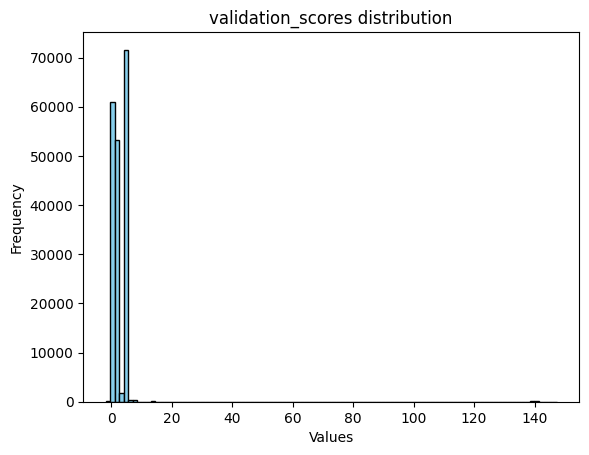

In [10]:
# get Validation scores
validation_scores = model.decision_function(X_validation)

# Plotting a basic histogram
plt.hist(validation_scores, bins=100, color='skyblue', edgecolor='black')

# Adding labels and title
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('validation_scores distribution')

188967 rows before feature engineering
188967 rows after merging parent process info
188967 rows after frequency encoding
188967 Null value counts after imputation
parent_timestamp null value count: 43531
188967 rows after processing parent and child process info and relationship
188967 rows after processing stackAddresses info
188967 rows after processing arg info
y_true_Validation Dataset Unique values: [0]
y_true_Validation Dataset Counts of each value: [188967]
y_pred_Validation Dataset Unique values: [0 1]
y_pred_Validation Dataset Counts of each value: [184523   4444]
Confusion Matrix:
[[184523   4444]
 [     0      0]]


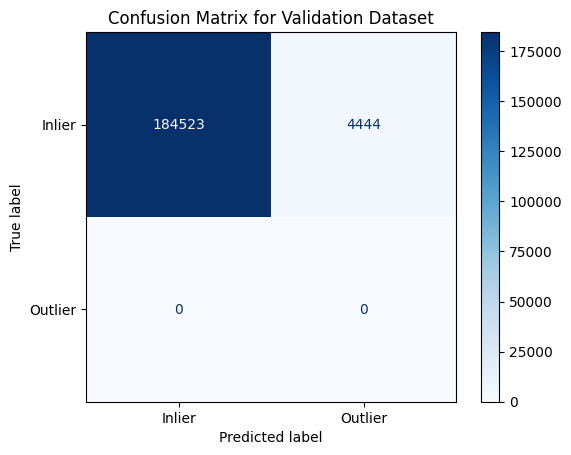

False Positive Rate: [0.         0.02351733 1.        ]
True Positive Rate: [nan nan nan]
False Negative Rate: [nan nan nan]
True Negative Rate: [1.         0.97648267 0.        ]


/Users/cheesecake/.pyenv/versions/anamoly-detection/lib/python3.14/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/cheesecake/.pyenv/versions/anamoly-detection/lib/python3.14/site-packages/sklearn/metrics/_ranking.py:1303: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


In [11]:
y_pred_validation = (model.predict(X_validation) == -1).astype(int)
evaluate_model(y_validation, y_pred_validation, dataset_type="Validation Dataset")

In [12]:
coef = model.named_steps["clf"].coef_.ravel()
features = model.named_steps["scaler"].get_feature_names_out()

importance = sorted(zip(features, coef), key=lambda x: abs(x[1]), reverse=True)

for f, w in importance[:20]:
    print(f, w)

binary__parentUserId_binary 1.5527412502702855
binary__userId_binary 1.5420534257524008
pass__argsNum 1.5213972869717451
rarity__parentProcessId_rarity 0.17615898802335414
count__parentProcessId_past_count 0.14901789379148575
count__eventId_past_count 0.14701933886765325
rarity__eventId_rarity 0.11844353711093031
count__mountNamespace_past_count -0.08518321215689938
count__userId_past_count -0.08481376154629566
count__processId_eventId_past_count 0.06374981332405448
scale_other__child_process_spawn_rate_so_far -0.056825684221221535
count__processId_past_count -0.04480612500426922
count__threadId_past_count -0.039880650403137964
rarity__processId_eventId_rarity -0.03568805817580405
binary__processId_eventId_is_first_seen 0.030648277886638757
scale_other__stackAddresses_len 0.01997951324295398
pass__returnValue 0.018092585686500164
scale_other__stackAddresses_unique_ratio 0.009091560044730992
rarity__threadId_rarity -0.00722389553415551
rarity__processId_rarity -0.0064304275480168375


### Model Evaluation

188967 rows before feature engineering
188967 rows after merging parent process info
188967 rows after frequency encoding
188967 Null value counts after imputation
parent_timestamp null value count: 8925
188967 rows after processing parent and child process info and relationship
188967 rows after processing stackAddresses info
188967 rows after processing arg info


Text(0.5, 1.0, 'test_scores distribution')

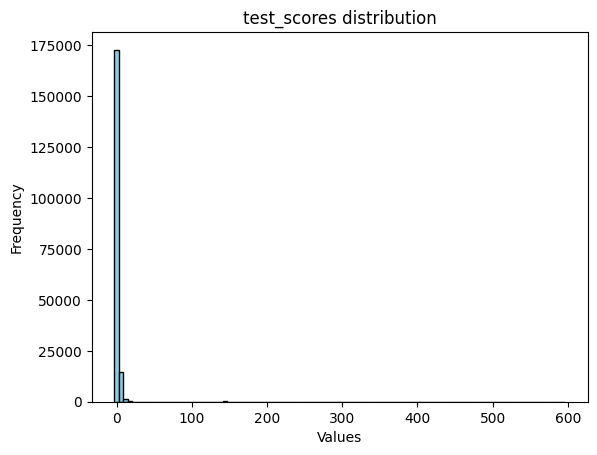

In [13]:
# get test scores
test_scores = model.decision_function(X_test)

# Plotting a basic histogram
plt.hist(test_scores, bins=100, color='skyblue', edgecolor='black')

# Adding labels and title
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('test_scores distribution')

Predict on test data...
188967 rows before feature engineering
188967 rows after merging parent process info
188967 rows after frequency encoding
188967 Null value counts after imputation
parent_timestamp null value count: 8925
188967 rows after processing parent and child process info and relationship
188967 rows after processing stackAddresses info
188967 rows after processing arg info
y_true_Test Dataset Unique values: [0 1]
y_true_Test Dataset Counts of each value: [ 30535 158432]
y_pred_Test Dataset Unique values: [0 1]
y_pred_Test Dataset Counts of each value: [ 37467 151500]
Confusion Matrix:
[[ 29657    878]
 [  7810 150622]]


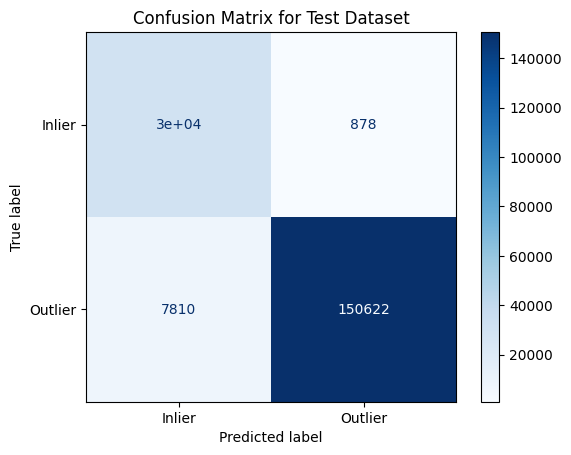

False Positive Rate: [0.         0.02875389 1.        ]
True Positive Rate: [0.        0.9507044 1.       ]
False Negative Rate: [1.        0.0492956 0.       ]
True Negative Rate: [1.         0.97124611 0.        ]


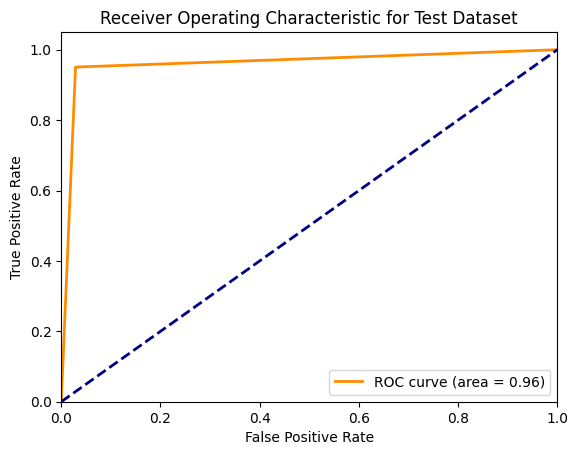

In [14]:
print("Predict on test data...")
y_pred_test = (model.predict(X_test) == -1).astype(int)
evaluate_model(y_test, y_pred_test, dataset_type="Test Dataset")